## 0- Prerequisite, Packages Imports and Data Imports

This section ensures all required Python libraries are imported and that the dataset is successfully loaded into memory. The imported packages provide functionalities for data handling, visualization, modeling, and explainability.<br>
The data import cell reads the event log and confirms its structure through dimensionality checks and sampling a few rows. This step ensures that the dataset is accessible, correctly formatted, and ready for subsequent analysis.

In [1]:
# This is used to download pm4py
#!pip install pm4py

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import re
from typing import List

from pm4py.objects.log.util import dataframe_utils
from pm4py.objects.conversion.log import converter as log_converter
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner
from pm4py.visualization.heuristics_net import visualizer as hn_visualizer

from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, precision_recall_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.inspection import permutation_importance

from lime.lime_text import LimeTextExplainer
from lime.lime_tabular import LimeTabularExplainer

from collections import Counter

import shap

/Users/victor/.pyenv/versions/3.10.6/envs/lewagon/lib/python3.10/site-packages/seaborn/utils.py:10: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 1.23.2)
  from scipy import stats


In [6]:
your_path_to_csv = '/Users/victor/code/escp/thesis/Master-Thesis---Process-Mining-with-NLP/bpi2018_events.csv'
df = pd.read_csv(your_path_to_csv)

## 1- Data Exploration

### 1.1 – Basic Overview: Dimensions, Duplicates, Nulls

An initial overview of the dataset is performed to understand its shape and completeness.  
The following diagnostics are calculated:
- The number of rows and columns, representing events and attributes.  
- Duplicate event detection to ensure data uniqueness.  
- Missing-value counts to assess data quality and determine which columns may require cleaning or removal.  

This stage provides a quantitative baseline of data integrity before feature engineering.

In [7]:
# Dimensions
print("Shape:", df.shape)

Shape: (2057551, 75)


In [8]:
# Missing values
null_counts = df.isnull().sum().sort_values(ascending=False)
print("Null counts:\n", null_counts[null_counts > 0])

Null counts:
 case:amount_applied3    2055301
case:payment_actual3    2055301
case:penalty_amount3    2055301
case:amount_applied2    2035001
case:payment_actual2    2035001
case:penalty_amount2    2035001
case:amount_applied1    1797235
case:penalty_amount1    1797235
case:payment_actual1    1797235
eventid                  102302
note                       3920
dtype: int64


In [9]:
# Duplicates
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


### 1.2 – Drop Irrelevant Columns

Columns that do not contribute to process analysis or modeling are removed.  
These include unique identifiers, system-generated metadata, and fields with excessive missing values.  

This step reduces noise and improves computational efficiency while retaining all columns that convey process-related or semantic meaning.

In [10]:
# Drop if too many NaNs (> 98%)
too_null = df.columns[df.isnull().mean() > 0.98].tolist()
df_cleaned = df.drop(columns=too_null)

In [11]:
df_cleaned.shape

(2057551, 69)

### 1.3 – Understand Target: “success”

The `success` field is analyzed to confirm its definition and consistency across events within each case.  
Cases are grouped by their identifiers to check whether the success label remains uniform or varies across activities.  

This exploration helps define a meaningful case-level target later in the pipeline.  
The results of this analysis guide whether success should be defined as the last event’s status, or as all events being successful.

In [12]:
# How many unique cases?
print("Unique cases:", df_cleaned['case:concept:name'].nunique())

Unique cases: 36000


In [13]:
# How is success distributed?
print(df_cleaned['success'].value_counts())

True     2036893
False      20658
Name: success, dtype: int64


In [14]:
# Group by case to check consistency
success_per_case = df_cleaned.groupby('case:concept:name')['success'].nunique()
print("Cases with inconsistent success labels:", (success_per_case > 1).sum())

Cases with inconsistent success labels: 11137


In [15]:
df_sorted = df_cleaned.sort_values('time:timestamp')
last_success = df_sorted.groupby('case:concept:name').tail(1)[['case:concept:name', 'success']]

In [16]:
last_success['success'].value_counts()

True     35936
False       64
Name: success, dtype: int64

In [17]:
df_cleaned['activity'].value_counts()

calculate                     380918
finish editing                355622
begin editing                 303842
save                          248786
initialize                    172615
decide                         79418
begin payment                  71426
performed                      68259
mail valid                     66303
insert document                65422
finish payment                 38149
mail income                    35999
abort payment                  33277
create                         29794
revoke decision                21848
check                          13588
finish pre-check               11691
finish preparations            10878
begin preparations             10876
prepare external                8162
abort external                  6318
remove document                 5157
plan                            4389
clear                           2367
begin admissibility check       1888
check admissibility             1819
prepare offline                 1581
p

### 1.4 – Identify Useful Text Fields

All potentially relevant text columns are reviewed to determine their usefulness for Natural Language Processing (NLP) later in the workflow.  
Columns such as `note`, `activity`, `subprocess`, and `doctype` are prioritized if they contain meaningful textual information rather than system codes or placeholders.  

This selection ensures that only semantically rich attributes contribute to the textual representation of each case.

In [18]:
text_cols = ['note', 'activity', 'subprocess', 'doctype']
for col in text_cols:
    print(f"\nTop values in {col}:")
    print(df_cleaned[col].value_counts().head(10))


Top values in note:
none                                       1038625
automatic                                   787956
automatic during payment                    142852
notification for applicant                   35030
created                                      29794
change by department                         12115
manual note                                   4067
objection                                     1564
attachment                                     217
Gesamtparzelle 35 berechnet und geprüft        179
Name: note, dtype: int64

Top values in activity:
calculate          380918
finish editing     355622
begin editing      303842
save               248786
initialize         172615
decide              79418
begin payment       71426
performed           68259
mail valid          66303
insert document     65422
Name: activity, dtype: int64

Top values in subprocess:
Application    785333
Main           764621
Declared       150698
Reported       126604
On-Site        

In [19]:
df_cleaned['concept:name']

0             mail income
1              mail valid
2              mail valid
3              mail valid
4              initialize
                ...      
2057546    finish editing
2057547     begin editing
2057548         calculate
2057549    finish editing
2057550            decide
Name: concept:name, Length: 2057551, dtype: object

## 2 – Data Cleaning & Feature Exploration

### 2.1 — Fix and Format Timestamps

The `time:timestamp` column is converted to a standardized datetime format.  
This conversion ensures correct chronological ordering of events within each case and enables time-based feature creation (for example, duration or inter-event gaps).  

This step guarantees temporal consistency for both process mining and performance analysis.

In [20]:
df_cleaned['time:timestamp'] = pd.to_datetime(df_cleaned['time:timestamp'], errors='coerce')

### 2.2 — Text Cleanup on note

Textual cleaning is applied to the `note` field, which often contains administrative phrases or placeholders such as “none.”  
Transformations include:
- Conversion to lowercase,  
- Removal of placeholder tokens,  
- Stripping of unnecessary spaces.  

This preprocessing step prepares text attributes for later aggregation and vectorization, improving the quality of textual features.

In [21]:
df_cleaned['note_cleaned'] = df_cleaned['note'].astype(str).str.strip().str.lower()

## 3 — Process Visualization and Case Variant Analysis

In this stage, we move from raw cleaning to understanding the process structure and behavior.
The goal is to discover patterns, bottlenecks, and deviations that connect to your thesis theme, showing how structured process attributes and textual elements jointly explain efficiency and success

### 3.1 Case-Level Metrics and Success Consistency

Case-level statistics are calculated, including:
- Number of activities per case,  
- Start and end timestamps,  
- Case duration in hours,  
- Internal consistency of success labels.  

This aggregation converts the event log into a structured case table, enabling comparisons of process length, duration, and success.


In [ ]:
CASE_COL = 'case:concept:name'
ACT_COL = 'activity'
TIME_COL = 'time:timestamp'
SUCCESS_COL = 'success'

df_cleaned[TIME_COL] = pd.to_datetime(df_cleaned[TIME_COL], errors='coerce')
df_cleaned = df_cleaned.dropna(subset=[CASE_COL, ACT_COL, TIME_COL]).sort_values([CASE_COL, TIME_COL])
df_cleaned['event_idx'] = df_cleaned.groupby(CASE_COL).cumcount()

case_agg = df_cleaned.groupby(CASE_COL).agg(
    n_events=('activity','size'),
    start_time=(TIME_COL,'min'),
    end_time=(TIME_COL,'max'),
    success_all=(SUCCESS_COL,'all'),
    success_any=(SUCCESS_COL,'any')
).reset_index()
case_agg['duration_hours']=(case_agg['end_time']-case_agg['start_time']).dt.total_seconds()/3600

last_ev=df_cleaned.sort_values([CASE_COL,TIME_COL]).groupby(CASE_COL).tail(1)[[CASE_COL,SUCCESS_COL]]
case_agg=case_agg.merge(last_ev.rename(columns={SUCCESS_COL:'success_last'}),on=CASE_COL,how='left')
case_agg.head()

,case:concept:name,n_events,start_time,end_time,success_all,success_any,duration_hours,success_last
0,0002505cb62792e4,56,2015-04-28 00:00:00+00:00,2017-08-03 15:54:21.311000+00:00,True,True,19887.905920,True
1,0002a55a6130cec8,40,2015-04-17 00:00:00+00:00,2016-02-18 07:41:46.343000+00:00,True,True,7375.696206,True
2,0004ff62053a60ce,51,2015-05-11 00:00:00+00:00,2016-08-19 11:56:47+00:00,True,True,11195.946389,True
3,000612b48d30de74,111,2015-05-06 00:00:00+00:00,2016-09-14 11:47:48.425000+00:00,False,True,11939.796785,True
4,0006cc909ce508b0,46,2016-04-28 00:00:00+00:00,2017-06-15 09:24:55+00:00,True,True,9921.415278,True


In [ ]:
n = case_agg["n_events"].astype(int)
q99 = np.percentile(n, 99)
share_trimmed = (n > q99).mean()

fig, ax = plt.subplots(figsize=(10,5))
sns.histplot(n[n <= q99], bins="fd", ax=ax)  # Freedman–Diaconis bins
ax.set(xlabel="Events per case", ylabel="Number of cases",
       title=f"Event count per case")
ax.axvline(n.mean(),   ls="--", lw=1, color="tab:orange", label=f"Mean={n.mean():.1f}")
ax.axvline(n.median(), ls="--", lw=1, color="tab:green",  label=f"Median={n.median():.1f}")
ax.legend(frameon=False); plt.tight_layout()


### 3.2 Identify Best vs Worst Cases

Cases are ranked according to their number of activities and duration.  
The most efficient (fewest activities or shortest duration) and least efficient (most activities or longest duration) cases are extracted.  

These subsets are later used to visualize and contrast process behavior under different performance conditions.

In [23]:
min_len, max_len = case_agg['n_events'].min(), case_agg['n_events'].max()
min_dur, max_dur = case_agg['duration_hours'].min(), case_agg['duration_hours'].max()

cases_min_len = case_agg.loc[case_agg['n_events']==min_len,CASE_COL].tolist()
cases_max_len = case_agg.loc[case_agg['n_events']==max_len,CASE_COL].tolist()
cases_min_dur = case_agg.loc[case_agg['duration_hours']==min_dur,CASE_COL].tolist()
cases_max_dur = case_agg.loc[case_agg['duration_hours']==max_dur,CASE_COL].tolist()

sample_cases = {
    'fewest_activities': cases_min_len,
    'most_activities': cases_max_len,
    'shortest_duration': cases_min_dur,
    'longest_duration': cases_max_dur,
}
sample_cases


{'fewest_activities': ['e464e72a43e59a55'],
 'most_activities': ['93deb55be9aed2be'],
 'shortest_duration': ['0c9042c6323fc971'],
 'longest_duration': ['ed78be965bdecdb8']}

### 3.3 Directly-Follows Graph (DFG) Frequencies

A Directly-Follows Graph is constructed to represent the process control flow.  
Each node corresponds to an activity, and each edge represents a transition between consecutive activities.  

Edge frequencies indicate how often transitions occur, providing insight into dominant paths and process loops.

In [23]:
df_pairs = (
    df[[CASE_COL,TIME_COL,ACT_COL]]
    .sort_values([CASE_COL,TIME_COL])
    .assign(next_act=lambda x: x.groupby(CASE_COL)[ACT_COL].shift(-1))
    .dropna(subset=['next_act'])
)
dfg = (
    df_pairs.groupby([ACT_COL,'next_act'])
    .size().reset_index(name='count')
    .sort_values('count',ascending=False)
)
dfg.head(20)


,activity,next_act,count
115,calculate,finish editing,231842
39,begin editing,calculate,197780
546,save,save,128631
306,initialize,begin editing,123869
225,finish editing,begin editing,122102
105,calculate,calculate,82891
237,finish editing,decide,75315
46,begin editing,finish editing,56202
243,finish editing,initialize,52492
319,initialize,performed,35996


### 3.4 Performance DFG (Average Transition Time)

The DFG is extended by adding timing information.  
Average durations between transitions are computed to identify slow segments of the process.  

This view combines control-flow and performance perspectives, supporting detection of bottlenecks and inefficiencies.

In [24]:
df_delta = df_cleaned.sort_values([CASE_COL,TIME_COL])
df_delta['next_act'] = df_delta.groupby(CASE_COL)[ACT_COL].shift(-1)
df_delta['next_time'] = df_delta.groupby(CASE_COL)[TIME_COL].shift(-1)
df_delta = df_delta.dropna(subset=['next_act','next_time'])
df_delta['delta_hours']=(df_delta['next_time']-df_delta[TIME_COL]).dt.total_seconds()/3600

perf_dfg = (
    df_delta.groupby([ACT_COL,'next_act'])
    .agg(n_transitions=('delta_hours','size'),
         avg_hours=('delta_hours','mean'),
         p50_hours=('delta_hours','median'),
         p90_hours=('delta_hours',lambda s:s.quantile(0.9)))
    .reset_index()
    .sort_values('avg_hours',ascending=False)
)
perf_dfg.head(20)


,activity,next_act,n_transitions,avg_hours,p50_hours,p90_hours
274,finish payment,revoke decision,2,10881.083040,10881.083040,12113.942326
264,finish payment,change department,5,6926.173967,6835.992468,12223.357364
277,finish payment,take original document,1,6622.361596,6622.361596,6622.361596
262,finish payment,begin admissibility check,6,5069.852001,4629.024691,8880.940665
269,finish payment,insert document,3260,4642.253812,3934.690673,8910.803121
263,finish payment,begin editing,1040,3874.194886,3825.194914,7802.677511
276,finish payment,save,5849,3861.388399,3511.991453,8160.735232
270,finish payment,plan,3,3706.286001,2138.899424,7512.804622
267,finish payment,finish editing,289,3473.132046,1826.724938,9586.064516
182,create,correction GFM17,4,3432.135960,3432.110749,3432.460268


### 3.5 Variants and Outcome Comparison

Activity sequences are grouped by unique patterns (variants).  
The frequency and success rate of each variant are compared, connecting behavioral patterns with outcomes.  

This step demonstrates how process structure influences success likelihood.

In [25]:
seq = (
    df_cleaned.sort_values([CASE_COL,TIME_COL])
      .groupby(CASE_COL)[ACT_COL].apply(list).rename('variant_list').to_frame()
)
seq['variant']=seq['variant_list'].apply(lambda xs:' > '.join(xs))
seq=seq.join(case_agg.set_index(CASE_COL)[['success_last']],how='left')

variant_counts=seq.groupby('variant').size().reset_index(name='count').sort_values('count',ascending=False)
variant_by_outcome=(seq.groupby(['variant','success_last']).size().reset_index(name='count'))
variant_by_outcome_pivot=(
    variant_by_outcome.pivot(index='variant',columns='success_last',values='count')
    .fillna(0).rename(columns={False:'count_failed',True:'count_success'}).reset_index()
    .merge(variant_counts,on='variant',how='left').sort_values('count',ascending=False)
)
variant_by_outcome_pivot.head(20)


,variant,count_failed,count_success,count
4681,mail income > mail valid > initialize > begin ...,0.0,1182.0,1182
4739,mail income > mail valid > initialize > begin ...,0.0,987.0,987
4485,mail income > mail valid > initialize > begin ...,0.0,448.0,448
4452,mail income > mail valid > initialize > begin ...,0.0,443.0,443
7925,mail income > mail valid > initialize > begin ...,0.0,406.0,406
10026,mail income > mail valid > mail valid > mail v...,0.0,243.0,243
10363,mail income > mail valid > mail valid > mail v...,0.0,216.0,216
4659,mail income > mail valid > initialize > begin ...,0.0,207.0,207
10081,mail income > mail valid > mail valid > mail v...,0.0,194.0,194
6532,mail income > mail valid > initialize > begin ...,0.0,185.0,185


In [ ]:
# Most frequent path
variant_by_outcome_pivot['variant'].iloc[0]


'mail income > mail valid > initialize > begin editing > finish editing > create > initialize > begin editing > finish editing > initialize > performed > performed > initialize > begin editing > calculate > calculate > calculate > calculate > finish editing > begin editing > calculate > finish editing > begin editing > calculate > finish editing > begin editing > calculate > finish editing > begin editing > calculate > finish editing > decide > revoke decision > calculate > finish editing > decide > begin payment > abort payment > begin payment > insert document > finish payment'

### 3.6 Representative Trace Extraction

A few representative cases from each extreme category are extracted (shortest, longest, simplest, and most complex).  
These traces are used for qualitative comparison and visualization, enabling interpretation of operational differences between efficient and inefficient process paths.

In [26]:
def get_trace(case_id):
    tmp = df_cleaned.loc[df[CASE_COL]==case_id,[CASE_COL,TIME_COL,ACT_COL,SUCCESS_COL]].sort_values(TIME_COL)
    return tmp

rep_few, rep_many = cases_min_len[:3], cases_max_len[:3]
rep_fast, rep_slow = cases_min_dur[:3], cases_max_dur[:3]

examples = {
    'fewest_activities_traces':[get_trace(c) for c in rep_few],
    'most_activities_traces':[get_trace(c) for c in rep_many],
    'shortest_duration_traces':[get_trace(c) for c in rep_fast],
    'longest_duration_traces':[get_trace(c) for c in rep_slow],
}
examples.keys()

dict_keys(['fewest_activities_traces', 'most_activities_traces', 'shortest_duration_traces', 'longest_duration_traces'])

### Step 3.7 — Process Visualization (Overall + Representative Subsets)

#### Overall Process — baseline control-flow structure and dominant paths

A global process model is visualized to illustrate the typical control-flow of all cases combined.  
This serves as a reference model for comparison against subsets of interest.

python(60388) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



--- Overall Process Model ---


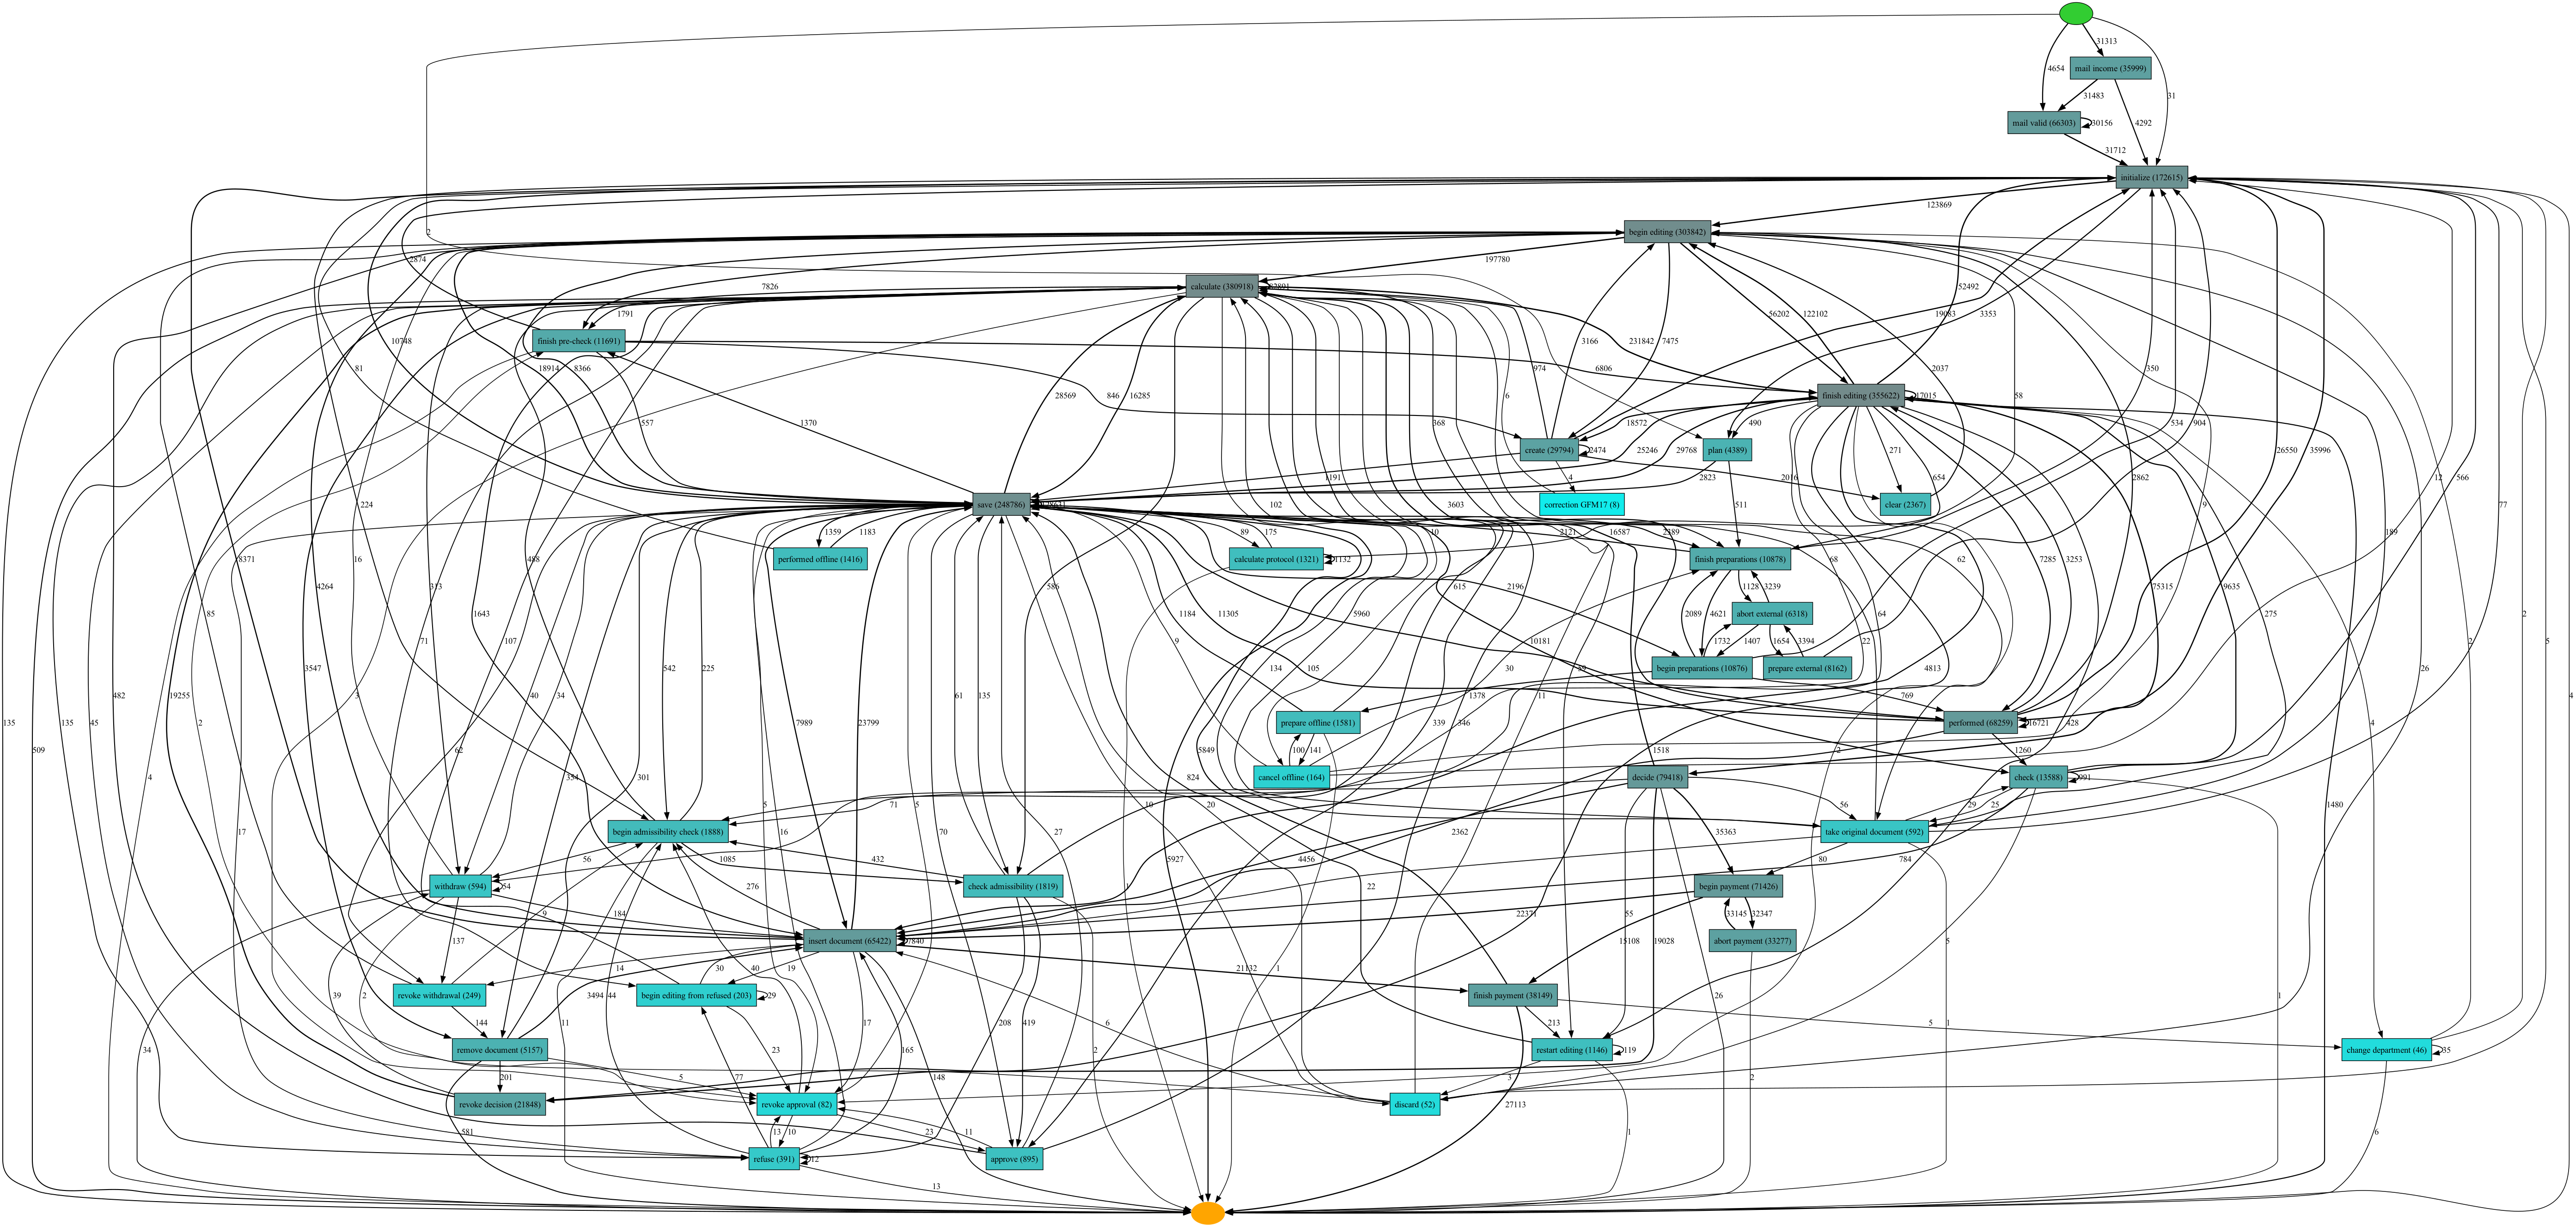

In [27]:
def visualize_process(df_subset, title):
    df_pm = df_subset[[CASE_COL, ACT_COL, TIME_COL]].copy()
    df_pm.columns = ["case:concept:name", "concept:name", "time:timestamp"]
    df_pm = dataframe_utils.convert_timestamp_columns_in_df(df_pm)
    event_log = log_converter.apply(df_pm)
    heu_net = heuristics_miner.apply_heu(event_log)
    gviz = hn_visualizer.apply(heu_net)
    print(f"\n--- {title} ---")
    hn_visualizer.view(gviz)

visualize_process(df_cleaned, "Overall Process Model")

#### Fewest Activities Cases — streamlined paths (minimal steps)

The simplest cases are visualized to identify ideal execution paths with minimal rework.

python(60474) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



--- Fewest Activities — Process Model ---


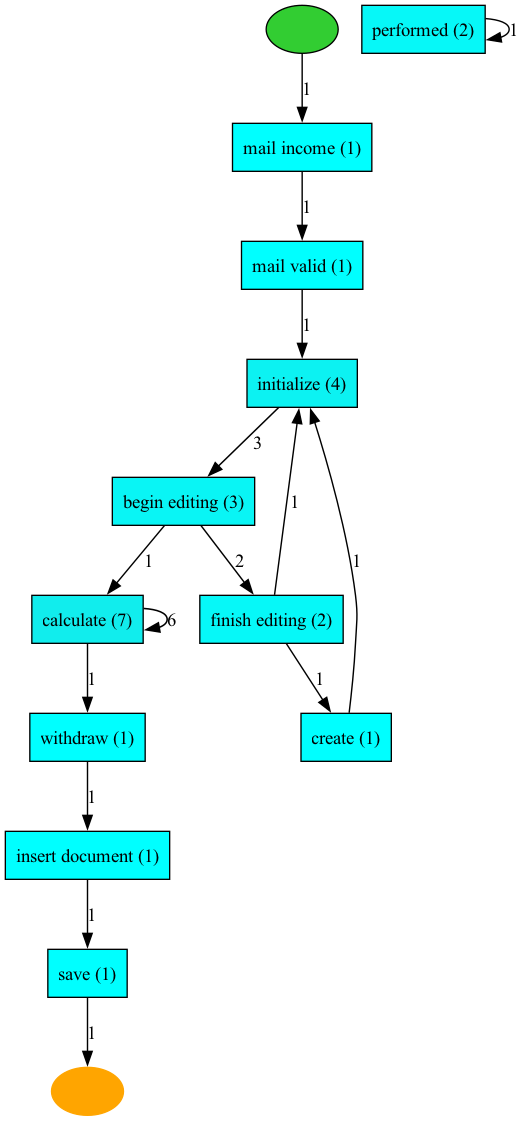

In [ ]:
subset_df = pd.concat(examples["fewest_activities_traces"], ignore_index=True)
visualize_process(subset_df, "Fewest Activities — Process Model")

#### Most Activities Cases — complex paths (loops/rework likely)

The most complex cases are visualized to highlight deviations, rework loops, or excessive manual handling.

python(60475) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



--- Most Activities — Process Model ---


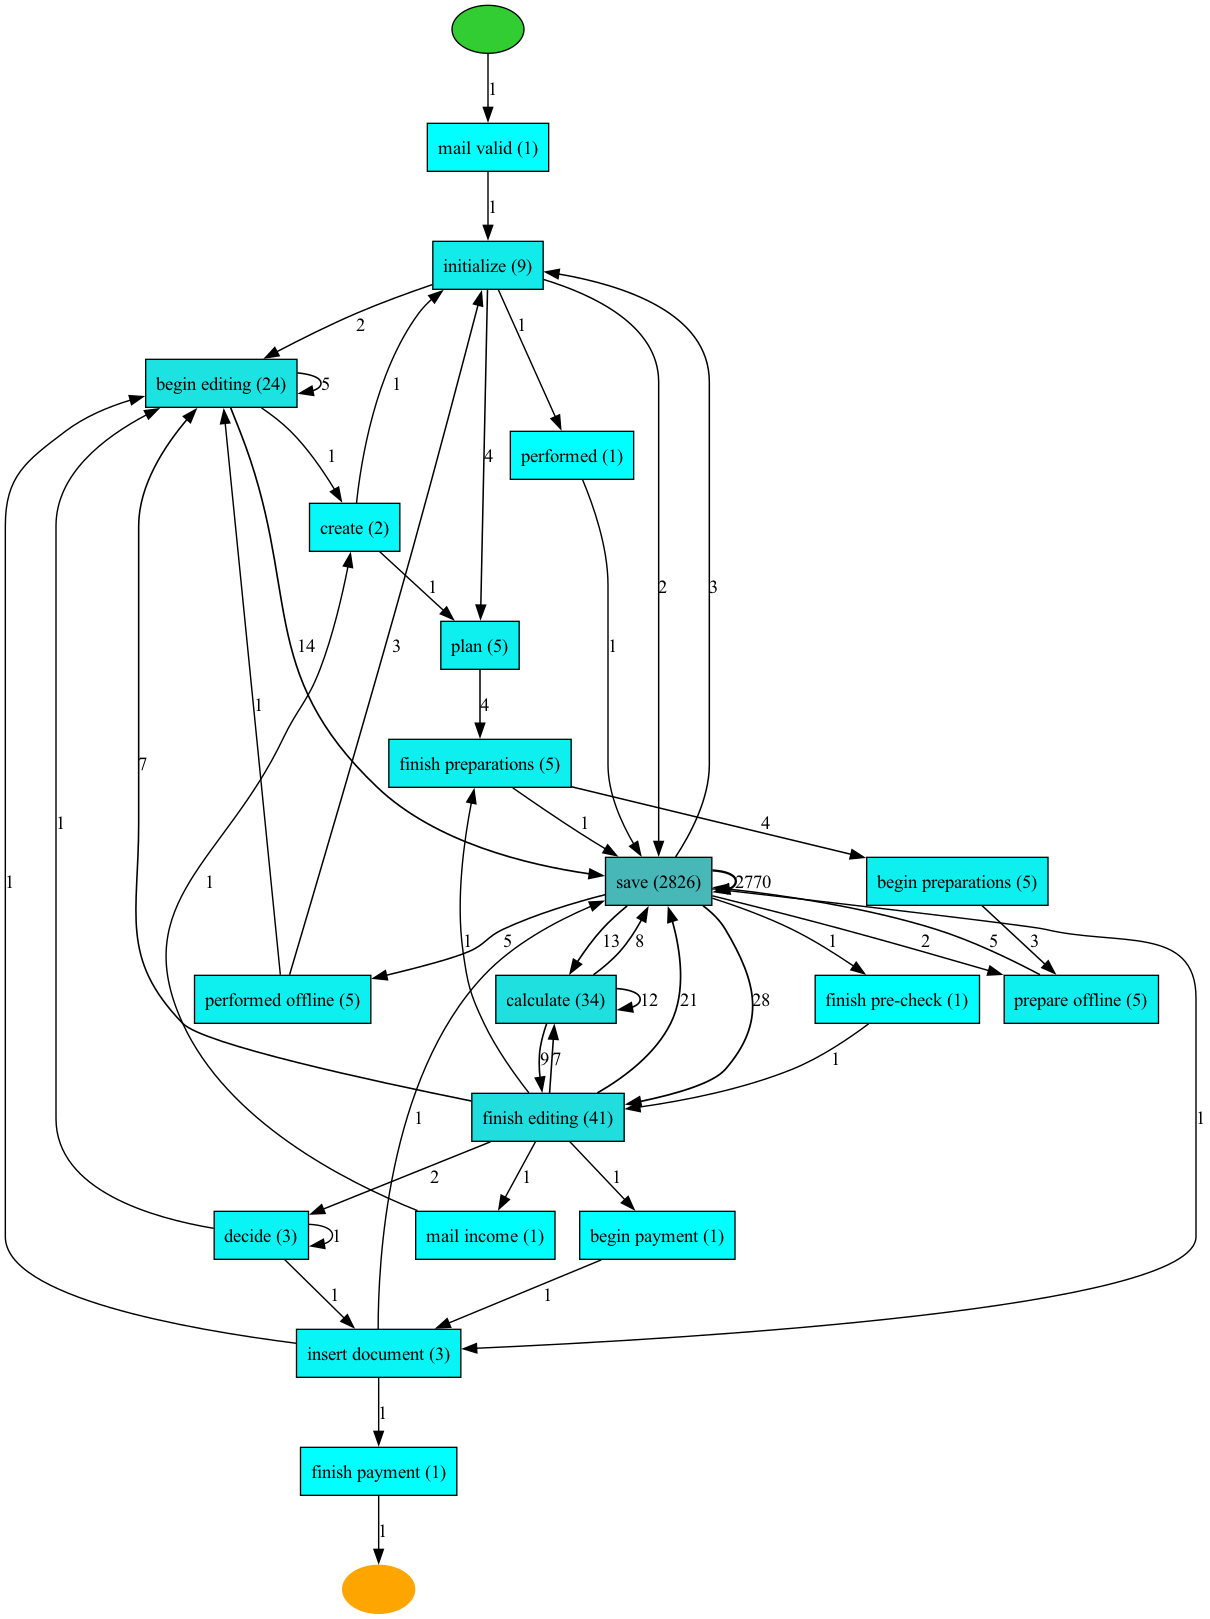

In [ ]:
subset_df = pd.concat(examples["most_activities_traces"], ignore_index=True)
visualize_process(subset_df, "Most Activities — Process Model")

#### Shortest Duration Cases — fastest executions

The cases with the shortest completion time are displayed, often representing automated or optimized workflows.


python(60476) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



--- Shortest Duration — Process Model ---


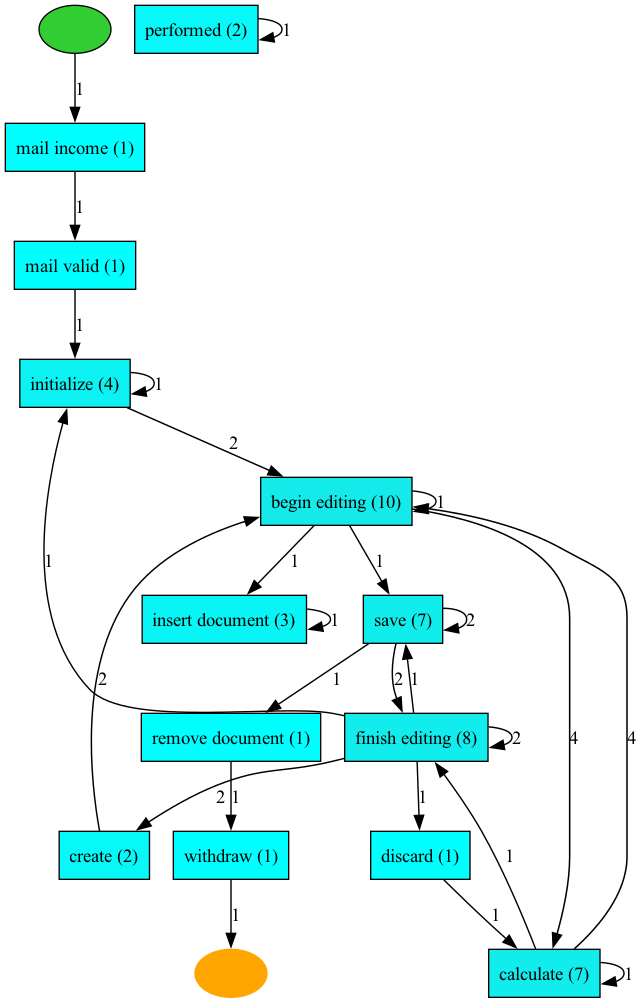

In [ ]:
subset_df = pd.concat(examples["shortest_duration_traces"], ignore_index=True)
visualize_process(subset_df, "Shortest Duration — Process Model")

#### Longest Duration Cases — slow executions / bottlenecks

Cases with the longest duration are analyzed to locate bottlenecks or dependencies causing extended delays.

python(60492) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



--- Longest Duration — Process Model ---


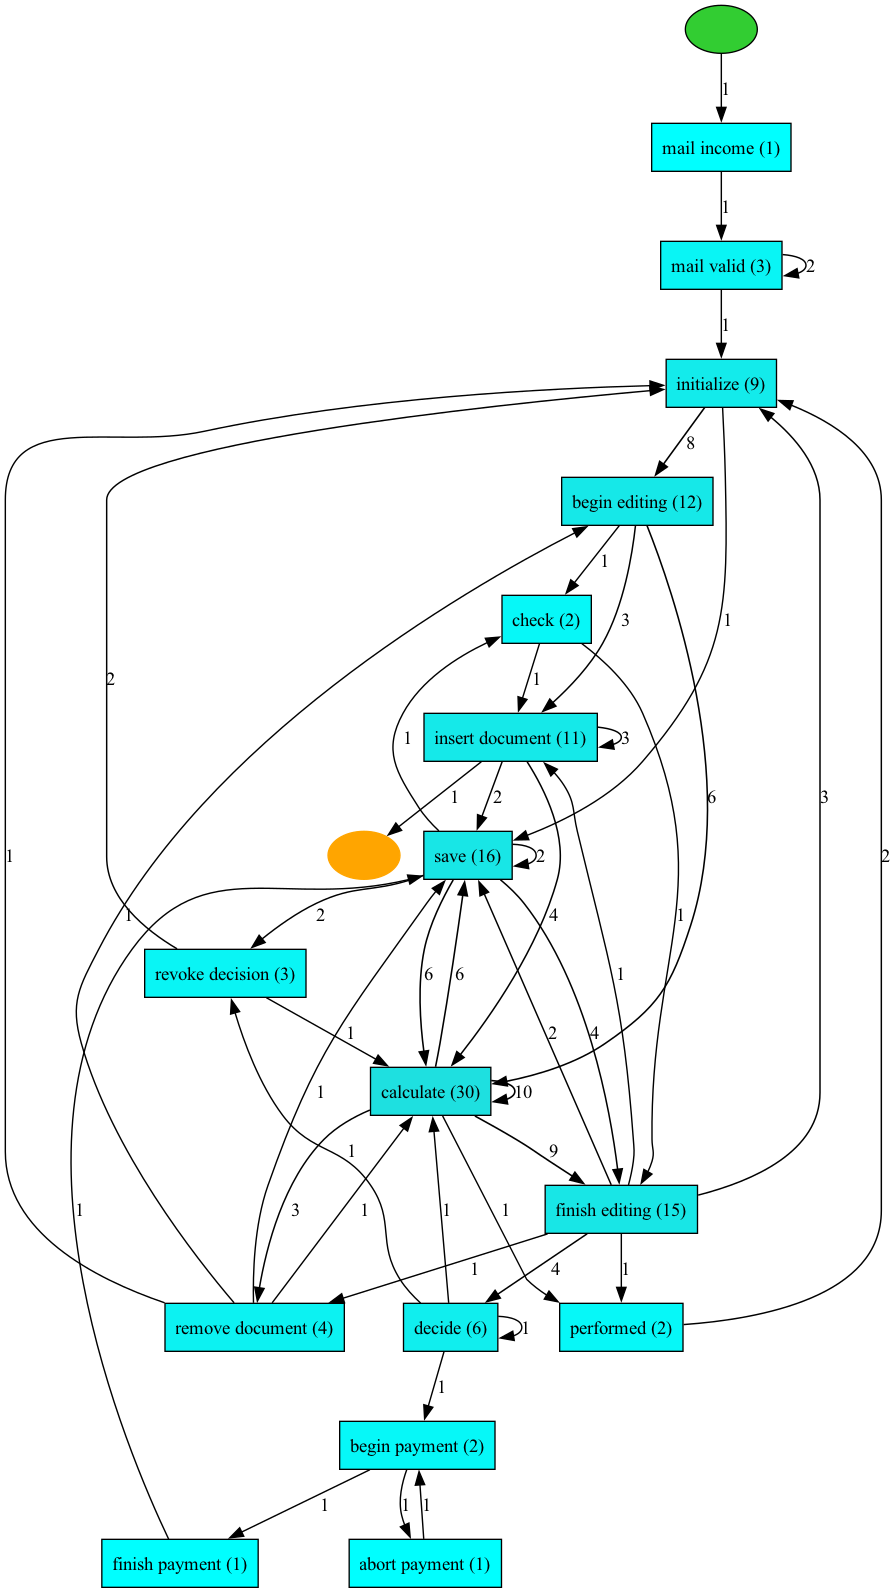

In [ ]:
subset_df = pd.concat(examples["longest_duration_traces"], ignore_index=True)
visualize_process(subset_df, "Longest Duration — Process Model")

## 4 — Case-Level Preprocessing Pipelines

### 4.0 — Setup & Target

The event log is ordered chronologically per case, and a target variable `target_success` is created.  
A case is labeled as successful only if all its events are marked as successful.  

This transformation prepares the data for case-level machine learning.

In [ ]:
CASE_COL    = 'case:concept:name'
TIME_COL    = 'time:timestamp'
ACT_COL     = 'activity'
SUCCESS_COL = 'success'

# Ensure ordering and event index
df_cleaned = df_cleaned.dropna(subset=[CASE_COL, ACT_COL, TIME_COL]).sort_values([CASE_COL, TIME_COL]).copy()
df_cleaned['event_idx'] = df_cleaned.groupby(CASE_COL).cumcount()


def make_case_target(dfc, strategy="all_success", end_activities=None):
    """
    strategy:
      - 'all_success': 1 only if ALL events success=True (0 if ANY failed)
      - 'last_event' : 1 if LAST event success=True
      - 'end_event_rule': 1 if LAST activity in end_activities AND success=True
    """
    if strategy == "all_success":
        ser = dfc.groupby(CASE_COL)[SUCCESS_COL].agg(lambda s: int(s.all()))
        return ser.to_frame("target_success")

    if strategy == "last_event":
        last = (dfc.sort_values([CASE_COL, TIME_COL])
                   .groupby(CASE_COL).tail(1)[[CASE_COL, SUCCESS_COL]])
        return last.rename(columns={SUCCESS_COL: "target_success"}).set_index(CASE_COL)

    if strategy == "end_event_rule":
        assert end_activities, "Provide end_activities list"
        last = (dfc.sort_values([CASE_COL, TIME_COL])
                   .groupby(CASE_COL).tail(1)[[CASE_COL, ACT_COL, SUCCESS_COL]])
        last["target_success"] = (last[ACT_COL].isin(end_activities) & last[SUCCESS_COL]).astype(int)
        return last.set_index(CASE_COL)[["target_success"]]

    raise ValueError("Unknown strategy")

case_target = make_case_target(df, strategy="all_success")

1    24863
0    11137
Name: target_success, dtype: int64


In [ ]:
# Target distribution

dist = case_target["target_success"].value_counts().rename(index={0:"Failure",1:"Success"}).reset_index()
dist.columns = ["class","count"]
dist["pct"] = dist["count"] / dist["count"].sum()

fig, ax = plt.subplots(figsize=(6,5))
sns.barplot(data=dist, x="class", y="count", ax=ax)
ax.bar_label(ax.containers[0], labels=[f"{p*100:.1f}%" for p in dist["pct"].to_numpy()])
ax.set(ylabel="Cases", xlabel="", title="Outcome distribution")
plt.tight_layout()

In [ ]:
# Top activites and average success

act_counts = df_cleaned.groupby("activity").size().rename("count")
act_succ = (df_cleaned
            .merge(case_target, left_on="case:concept:name", right_index=True)
            .groupby("activity")["target_success"].mean().rename("avg_success"))
act_stats = (pd.concat([act_counts, act_succ], axis=1)
               .sort_values("count", ascending=False)
               .head(20)
               .reset_index())

# map avg_success → colors
norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = mpl.cm.viridis
colors = [cmap(norm(v)) for v in act_stats["avg_success"].to_numpy()]

fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(data=act_stats, x="activity", y="count", palette=colors, ax=ax)
ax.set(xlabel="", ylabel="Event count", title="Top activities (color = avg. success)")
ax.tick_params(axis="x", rotation=60)
# colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cbar = plt.colorbar(sm, ax=ax); cbar.set_label("Avg. success")
plt.tight_layout()

### 4.1 — Numeric-Only Case Table + Preprocessor

Numeric features are aggregated per case, including:
- Event count, duration, and time gaps,  
- Case-level numeric and boolean flags.  

Boolean columns are converted to binary (0/1).  
The department field is kept as a categorical variable to capture organizational context.  

A preprocessing pipeline is defined:
- Median imputation and standard scaling for numeric features,  
- One-hot encoding for department categories.  

This pipeline standardizes numerical input and prepares it for modeling.

In [ ]:
def build_case_numeric_bool_to_int(dfc: pd.DataFrame) -> pd.DataFrame:
    # base metrics
    base = dfc.groupby(CASE_COL).agg(
        n_events   =(ACT_COL,'size'),
        start_time =(TIME_COL,'min'),
        end_time   =(TIME_COL,'max')
    )
    base['duration_hours'] = (base['end_time'] - base['start_time']).dt.total_seconds()/3600

    # gaps
    tmp = dfc.sort_values([CASE_COL, TIME_COL]).copy()
    tmp['next_time'] = tmp.groupby(CASE_COL)[TIME_COL].shift(-1)
    gaps = (tmp['next_time'] - tmp[TIME_COL]).dt.total_seconds()/3600
    gap_stats = gaps.groupby(tmp[CASE_COL]).agg(['mean','median','std']).rename(
        columns={'mean':'gap_mean_h','median':'gap_median_h','std':'gap_std_h'}
    )

    # case-level numeric/bool (+ keep department as object)
    case_cols = [c for c in dfc.columns if c.startswith('case:') and c != CASE_COL]
    case_scalar = (
        dfc.groupby(CASE_COL)[case_cols].first()
           .select_dtypes(include=['float64','int64','bool','object'])
           .copy()
    )
    # bool → 0/1
    bool_cols = case_scalar.select_dtypes(include=['bool']).columns.tolist()
    if bool_cols:
        case_scalar[bool_cols] = case_scalar[bool_cols].astype('int8')

    # drop ID-like objects but KEEP department if present
    if 'case:department' in case_scalar.columns:
        obj_cols = case_scalar.select_dtypes(include=['object']).columns.tolist()
        drop_ids = [c for c in obj_cols if c != 'case:department' and any(k in c.lower() for k in ['uuid','id','identity','docid','concept:name'])]
        case_scalar = case_scalar.drop(columns=drop_ids, errors='ignore')
    else:
        case_scalar = case_scalar.select_dtypes(include=['float64','int64','int8'])

    # join pieces
    num_tbl = base.join([gap_stats, case_scalar], how='left').fillna(0)
    num_tbl = num_tbl.join(case_target, how='left').reset_index()

    return num_tbl

# build
num_tbl = build_case_numeric_bool_to_int(df_cleaned)
y_num   = num_tbl['target_success'].astype(int)
X_num   = num_tbl.drop(columns=['target_success','start_time','end_time'], errors='ignore')

# Numeric preprocessor: impute+scale numbers, OHE department
num_feature_cols = X_num.select_dtypes(include=['number']).columns.tolist()
cat_feature_cols = [c for c in ['case:department'] if c in X_num.columns]

numeric_preprocessor = ColumnTransformer([
    ('num',  Pipeline([('imp', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_feature_cols),
    ('dept', OneHotEncoder(handle_unknown='ignore', min_frequency=50), cat_feature_cols)
], remainder='drop')

print("X_num shape:", X_num.shape, "| y_num:", y_num.shape)

X_num shape: (36000, 60) | y_num: (36000,)


### 4.2 — Text-Only Case Table + Preprocessor

Selected textual attributes are combined into a single field, `text_doc`.  
Columns included are defined through a variable `TEXT_COLUMNS`, allowing flexibility.  
The text is lowercased, stripped, and any note equal to “none” is removed to eliminate placeholders.  

The preprocessing pipeline applies:
- TF-IDF vectorization (unigrams and bigrams),  
- Dimensionality reduction through Truncated SVD (300 components).  

This creates a compact numerical representation of textual semantics suitable for machine learning and explainable AI.

In [ ]:
TEXT_COLUMNS = [
    'doctype',
    'subprocess',
    'activity',
    'note',
    'concept:name',
    'lifecycle:transition'
]

if 'note_cleaned' in df_cleaned.columns and 'note' in TEXT_COLUMNS:
    TEXT_COLUMNS = [c if c!='note' else 'note_cleaned' for c in TEXT_COLUMNS]
TEXT_COLUMNS = [c for c in TEXT_COLUMNS if c in df_cleaned.columns]

def _clean_txt(x: str, is_note=False) -> str:
    s = str(x).lower().strip()
    if is_note and s == 'none':
        return ''
    s = re.sub(r'\s+', ' ', s)
    return s

def build_case_text_from_cols(dfc, cols):
    d = dfc[[CASE_COL] + cols].copy()
    for c in cols:
        d[c] = d[c].astype(str).map(lambda v: _clean_txt(v, is_note=(c in ['note','note_cleaned'])))
    per_col = [d.groupby(CASE_COL)[c].apply(lambda s: ' '.join([t for t in s if t])).rename(c) for c in cols]
    text_per_case = pd.concat(per_col, axis=1).fillna('')
    text_per_case['text_doc'] = text_per_case.apply(lambda r: ' | '.join([r[c] for c in cols if r[c]]), axis=1)
    text_per_case['text_doc'] = text_per_case['text_doc'].str.replace(r'\s+', ' ', regex=True).str.strip(' |')
    return text_per_case[['text_doc']].join(case_target, how='left').reset_index()

text_tbl = build_case_text_from_cols(df_cleaned, TEXT_COLUMNS)
y_text   = text_tbl['target_success'].astype(int)
X_text   = text_tbl['text_doc'].fillna('')

# Text preprocessor (letters ≥3, no digits) + SVD reduction
text_preprocessor = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=15000, ngram_range=(1,2), min_df=5,
        token_pattern=r'(?u)\b[^\W\d_]{3,}\b',
        strip_accents='unicode', lowercase=True
    )),
    ('svd', TruncatedSVD(n_components=250, random_state=42))
])

print("TEXT_COLUMNS:", TEXT_COLUMNS)
print("X_text length:", len(X_text), "| y_text:", y_text.shape)


TEXT_COLUMNS: ['doctype', 'subprocess', 'activity', 'note_cleaned', 'concept:name', 'lifecycle:transition']
X_text length: 36000 | y_text: (36000,)


### 4.3 — Combined Case Table + Preprocessor

The numeric and text tables are merged by case identifier, with optional addition of `start_activity` and `end_activity`.  

The combined preprocessor consists of:
- Imputation and scaling for numeric variables,  
- One-hot encoding for categorical variables (department, start/end activity),  
- TF-IDF + SVD transformation for text.  

This unified pipeline enables integrated modeling of structured process data and textual context.

In [35]:
# start/end activity
starts = (df_cleaned.groupby(CASE_COL).head(1)[[CASE_COL, ACT_COL]]
          .rename(columns={ACT_COL:'start_activity'}))
ends   = (df_cleaned.groupby(CASE_COL).tail(1)[[CASE_COL, ACT_COL]]
          .rename(columns={ACT_COL:'end_activity'}))
cats = starts.merge(ends, on=CASE_COL, how='outer')

# join numeric + cats + text
combined = (
    num_tbl[[CASE_COL,'target_success'] + [c for c in num_tbl.columns
                                           if c not in [CASE_COL,'target_success','start_time','end_time']]]
    .merge(cats, on=CASE_COL, how='left')
    .merge(text_tbl[[CASE_COL,'text_doc']], on=CASE_COL, how='left')
)

y_combined = combined['target_success'].astype(int)
feature_cols_num = combined.select_dtypes(include=['number']).columns.tolist()
if 'target_success' in feature_cols_num:
    feature_cols_num.remove('target_success')
feature_cols_cat = [c for c in ['start_activity','end_activity','case:department'] if c in combined.columns]
feature_cols_txt = ['text_doc']

X_combined = combined[feature_cols_num + feature_cols_cat + feature_cols_txt].drop(columns=['target_success'], errors='ignore')

combined_preprocessor = ColumnTransformer([
    ('num',  Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), feature_cols_num),

    ('cat',  Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', min_frequency=50))
    ]), feature_cols_cat),

    ('txt',  Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=15000, ngram_range=(1,2), min_df=5,
            token_pattern=r'(?u)\b[^\W\d_]{3,}\b',
            strip_accents='unicode', lowercase=True)),
        ('svd', TruncatedSVD(n_components=250, random_state=42))
    ]), 'text_doc')
], remainder='drop')

print("X_combined shape:", X_combined.shape, "| y_combined:", y_combined.shape)

X_combined shape: (36000, 60) | y_combined: (36000,)


In [125]:
combined_preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imp',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['n_events', 'duration_hours', 'gap_mean_h',
                                  'gap_median_h', 'gap_std_h',
                                  'case:young farmer', 'case:selected_random',
                                  'case:penalty_AJLP', 'case:penalty_amount0',
                                  'case:program-id', 'case:penalty_BGKV',
                                  'case:penalty_AUVP', 'case:risk_f...
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                min_frequency=50))]),
                                 ['start_activity', 'end_activity',
                                  'case:department']),
                                ('txt',
                                 Pipeline(steps=[('tfidf',
                                                  TfidfVectorizer(max_features=15000,
                                                                  min_df=5,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  strip_accents='unicode',
                                                                  token_pattern='(?u)\\b[^\\W\\d_]{3,}\\b')),
                                                 ('svd',
                                                  TruncatedSVD(n_components=250,
                                                               random_state=42))]),
                                 'text_doc')])

## 5 — Modeling & Evaluation (three independent pipelines)

### 5.0 — Metrics helper

Functions are defined to compute standard performance metrics: accuracy, F1-score, ROC-AUC, and the confusion matrix.  
This unified evaluation method ensures comparability across models.

In [38]:
def evaluate(y_true, y_pred, y_proba=None, title=""):
    if title: print(f"\n=== {title} ===")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("F1-score :", round(f1_score(y_true, y_pred), 4))
    if y_proba is not None:
        try:
            print("ROC-AUC  :", round(roc_auc_score(y_true, y_proba), 4))
        except Exception as e:
            print("ROC-AUC  : (n/a)", e)
    print("\nReport:\n", classification_report(y_true, y_pred, digits=4))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))


### 5.1 — Model A: Numeric-only (uses X_num, y_num, numeric_preprocessor)

The numeric pipeline is trained with a Random Forest classifier.  
The pipeline performs median imputation and scaling before training.  

This model evaluates predictive power based solely on structured process data such as duration and activity count.

In [39]:
RANDOM_STATE = 42

Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_num, y_num, test_size=0.2, random_state=RANDOM_STATE, stratify=y_num
)

numeric_model = Pipeline(steps=[
    ('imputer', numeric_preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=300, max_depth=None, n_jobs=-1, random_state=RANDOM_STATE
    ))
])

numeric_model.fit(Xn_train, yn_train)
yn_pred  = numeric_model.predict(Xn_test)
yn_proba = numeric_model.predict_proba(Xn_test)[:,1]

evaluate(yn_test, yn_pred, yn_proba, title="Numeric-only")

python(61164) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



=== Numeric-only ===
Accuracy : 0.9067
F1-score : 0.9348
ROC-AUC  : 0.9544

Report:
               precision    recall  f1-score   support

           0     0.9156    0.7692    0.8360      2227
           1     0.9035    0.9682    0.9348      4973

    accuracy                         0.9067      7200
   macro avg     0.9095    0.8687    0.8854      7200
weighted avg     0.9073    0.9067    0.9042      7200

Confusion matrix:
 [[1713  514]
 [ 158 4815]]


In [ ]:
pred = (numeric_model.predict_proba(Xn_test)[:,1] >= 0.5).astype(int)
cm = confusion_matrix(yn_test, pred, labels=[0,1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['pred 0','pred 1'], yticklabels=['true 0','true 1'])
plt.title("Numeric model – confusion matrix"); plt.show()

### 5.2 — Model B: Text-only (uses X_text, y_text, text_preprocessor)

The text pipeline is trained using a Logistic Regression classifier on the TF-IDF+SVD representation.  
This isolates the influence of textual information on process outcomes.  

Performance is assessed with the same metrics for comparability.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_text, y_text, test_size=0.2, random_state=RANDOM_STATE, stratify=y_text
)

text_model = Pipeline(steps=[
    ('tfidf', text_preprocessor),
    ('clf', LogisticRegression(
        max_iter=3000, solver='saga', penalty='l2', random_state=RANDOM_STATE
    ))
])

text_model.fit(Xt_train, yt_train)
yt_pred  = text_model.predict(Xt_test)
yt_proba = text_model.predict_proba(Xt_test)[:,1]

evaluate(yt_test, yt_pred, yt_proba, title="Text-only")



=== Text-only ===
Accuracy : 0.9264
F1-score : 0.9483
ROC-AUC  : 0.9757

Report:
               precision    recall  f1-score   support

           0     0.9403    0.8137    0.8724      2227
           1     0.9213    0.9769    0.9483      4973

    accuracy                         0.9264      7200
   macro avg     0.9308    0.8953    0.9103      7200
weighted avg     0.9272    0.9264    0.9248      7200

Confusion matrix:
 [[1812  415]
 [ 115 4858]]


In [ ]:
pred = (text_model.predict_proba(Xt_test)[:,1] >= 0.5).astype(int)
cm = confusion_matrix(yt_test, pred, labels=[0,1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['pred 0','pred 1'], yticklabels=['true 0','true 1'])
plt.title("Text only model – confusion matrix"); plt.show()

### 5.3 — Model C: Combined (uses X_combined, y_combined, combined_preprocessor)

The combined pipeline integrates numeric, categorical, and textual features.  
Logistic Regression is used to jointly model process and semantic information.  

The comparison of results across the three pipelines indicates whether textual data provides additional predictive value beyond structured attributes.

In [41]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_combined, y_combined, test_size=0.2, random_state=RANDOM_STATE, stratify=y_combined
)

combined_model = Pipeline(steps=[
    ('prep', combined_preprocessor),
    ('clf', LogisticRegression(
        max_iter=4000, solver='saga', penalty='l2', random_state=RANDOM_STATE
    ))
])

combined_model.fit(Xc_train, yc_train)
yc_pred  = combined_model.predict(Xc_test)
yc_proba = combined_model.predict_proba(Xc_test)[:,1]

evaluate(yc_test, yc_pred, yc_proba, title="Combined (numeric + categorical + text)")

/Users/victor/.pyenv/versions/3.10.6/envs/lewagon/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



=== Combined (numeric + categorical + text) ===
Accuracy : 0.921
F1-score : 0.9443
ROC-AUC  : 0.9676

Report:
               precision    recall  f1-score   support

           0     0.9238    0.8114    0.8640      2227
           1     0.9199    0.9700    0.9443      4973

    accuracy                         0.9210      7200
   macro avg     0.9219    0.8907    0.9041      7200
weighted avg     0.9211    0.9210    0.9195      7200

Confusion matrix:
 [[1807  420]
 [ 149 4824]]


In [ ]:
pred = (text_model.predict_proba(Xc_test)[:,1] >= 0.5).astype(int)
cm = confusion_matrix(yc_test, pred, labels=[0,1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['pred 0','pred 1'], yticklabels=['true 0','true 1'])
plt.title("Text only model – confusion matrix"); plt.show()

### 5.4 - Results Visualization of models

Comparaison of the three pipelines—numeric, text, and combined—using ROC/PR overlays and feature-importance summaries, highlighting both discrimination performance and the relative contributions of numeric vs. textual signals.

#### 5.4.1 ROC & PR curves (overlay for the three models)

The ROC and Precision–Recall curves compare classifier performance across the numeric, text, and combined models, showing differences in discrimination ability and calibration.

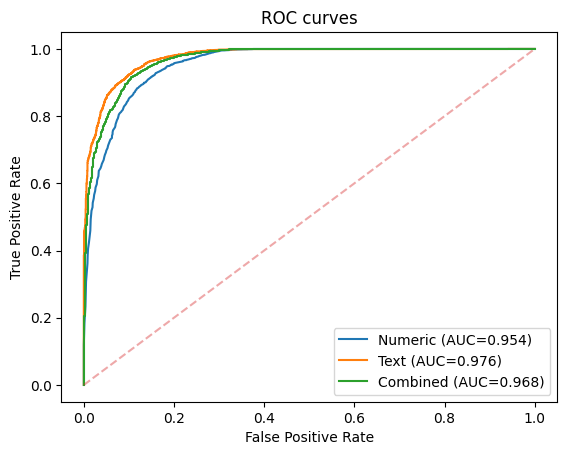

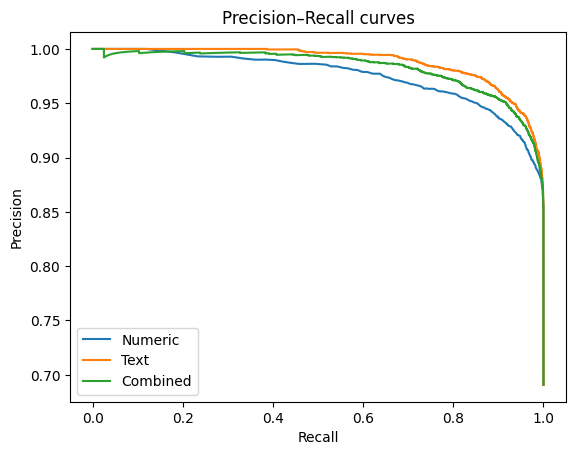

In [ ]:
proba_num = numeric_model.predict_proba(Xn_test)[:,1]
proba_txt = text_model.predict_proba(Xt_test)[:,1]
proba_cmb = combined_model.predict_proba(Xc_test)[:,1]

# ROC
fpr_n, tpr_n, _ = roc_curve(yn_test, proba_num)
fpr_t, tpr_t, _ = roc_curve(yt_test, proba_txt)
fpr_c, tpr_c, _ = roc_curve(yc_test, proba_cmb)

plt.figure()
plt.plot(fpr_n, tpr_n, label=f'Numeric (AUC={auc(fpr_n,tpr_n):.3f})')
plt.plot(fpr_t, tpr_t, label=f'Text (AUC={auc(fpr_t,tpr_t):.3f})')
plt.plot(fpr_c, tpr_c, label=f'Combined (AUC={auc(fpr_c,tpr_c):.3f})')
plt.plot([0,1],[0,1],'--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curves'); plt.legend(); plt.show()

In [ ]:
# PR
prec_n, rec_n, _ = precision_recall_curve(yn_test, proba_num)
prec_t, rec_t, _ = precision_recall_curve(yt_test, proba_txt)
prec_c, rec_c, _ = precision_recall_curve(yc_test, proba_cmb)

plt.figure()
plt.plot(rec_n, prec_n, label='Numeric')
plt.plot(rec_t, prec_t, label='Text')
plt.plot(rec_c, prec_c, label='Combined')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision–Recall curves'); plt.legend(); plt.show()

#### 5.4.2 Numeric model — permutation importance (top 20)

Displays the most influential numeric attributes based on permutation importance, highlighting variables with the strongest effect on predictive accuracy.

In [ ]:
num_ct = numeric_model.named_steps['imputer']
# Numeric block names
num_cols = num_ct.transformers_[0][2] if len(num_ct.transformers_) > 0 else []
# Dept OHE names (if present)
dept_names = []
for name, transformer, cols in num_ct.transformers_:
    if name == 'dept':
        ohe = transformer
        try:
            dept_names = list(ohe.get_feature_names_out(cols))
        except:
            dept_names = list(cols)

feat_names_num = list(num_cols) + list(dept_names)

r = permutation_importance(numeric_model, Xn_test, yn_test, n_repeats=5, random_state=42, n_jobs=-1)
imp = pd.DataFrame({'feature': feat_names_num, 'importance': r.importances_mean}).sort_values('importance', ascending=False)
display(imp.head(20))


python(66643) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(66644) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(66645) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(66646) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(66647) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(66648) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(66649) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(66650) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(66651) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/Users/victor/.pyenv/versions/3.10.6/envs/lewagon/lib/python3.10/site-packages/sklearn/utils/__init__.py:15: UserWarni

,feature,importance
51,case:number_parcels,0.235194
1,duration_hours,0.008222
18,case:penalty_CC,0.004000
59,case:department_e7,0.001722
4,gap_std_h,0.001556
57,case:department_6b,0.000750
3,gap_median_h,0.000556
7,case:penalty_AJLP,0.000389
39,case:basic payment,0.000222
13,case:small farmer,0.000194


#### 5.4.3. Text model — top positive / negative terms

Lists the textual tokens most associated with success and failure predictions, revealing key linguistic indicators captured by the model.

In [ ]:
prep = text_model.named_steps['tfidf']
tfidf = prep.named_steps['tfidf']
svd   = prep.named_steps['svd']
clf   = text_model.named_steps['clf']

# Terms in the TF-IDF vocab
terms = np.array(tfidf.get_feature_names_out())

# Map classifier coefficients (in SVD space) back to TF-IDF terms:
coef_svd = clf.coef_.ravel()
term_weights = coef_svd @ svd.components_

# Build tables
tw = pd.DataFrame({'term': terms, 'weight': term_weights})
top_pos = tw.sort_values('weight', ascending=False).head(30).reset_index(drop=True)
top_neg = tw.sort_values('weight', ascending=True ).head(30).reset_index(drop=True)

print("Top positive terms (push to success):")
display(top_pos)

print("\nTop negative terms (push to failure):")
display(top_neg)

Top positive terms (push to success):


,term,weight
0,automatic,7.477463
1,automatic automatic,7.341306
2,begin,5.922246
3,begin editing,5.238324
4,performed begin,3.896641
5,application application,2.926741
6,initialize,2.619801
7,initialize begin,2.604238
8,create begin,2.285210
9,main main,2.230963



Top negative terms (push to failure):


,term,weight
0,decide decide,-15.196235
1,reported,-9.486352
2,decision revoke,-9.011421
3,reported reported,-7.468806
4,save finish,-6.834332
5,finish editing,-5.773010
6,finish,-5.581476
7,editing save,-5.057300
8,document geo,-4.372087
9,geo,-4.322267


#### 5.4.4 Combined model — top features (num/cat/txt)

Summarizes the leading features from all data types in the combined model, illustrating the interaction between structured and textual predictors.

In [ ]:
prep = combined_model.named_steps['prep']
clf  = combined_model.named_steps['clf']

feat_names = prep.get_feature_names_out()

pretty = []
for n in feat_names:
    if n.startswith('num__'):
        pretty.append(n.replace('num__', 'NUM::'))
    elif n.startswith('cat__'):
        pretty.append(n.replace('cat__', 'CAT::'))
    elif n.startswith('txt__'):
        pretty.append(n.replace('txt__', 'TXT::'))
    else:
        pretty.append(n)

coef = clf.coef_.ravel()

print(f"names: {len(pretty)} | coefs: {len(coef)}")
assert len(pretty) == len(coef), "Feature-name length != coef length. Check ColumnTransformer fit."

feat_df = (pd.DataFrame({'feature': pretty, 'coef': coef})
             .sort_values('coef', ascending=False)
             .reset_index(drop=True))

print("Top positive features:")
display(feat_df.head(40))

print("\nTop negative features:")
display(feat_df.tail(40).iloc[::-1].reset_index(drop=True))


names: 321 | coefs: 321
Top positive features:


,feature,coef
0,TXT::truncatedsvd3,5.790404
1,TXT::truncatedsvd12,3.613381
2,TXT::truncatedsvd8,3.104053
3,TXT::truncatedsvd6,1.534529
4,TXT::truncatedsvd13,1.412267
5,TXT::truncatedsvd50,1.052675
6,TXT::truncatedsvd16,1.013179
7,TXT::truncatedsvd52,0.996901
8,NUM::gap_mean_h,0.914079
9,TXT::truncatedsvd11,0.799125



Top negative features:


,feature,coef
0,TXT::truncatedsvd14,-5.078219
1,TXT::truncatedsvd2,-4.215390
2,TXT::truncatedsvd4,-2.807092
3,TXT::truncatedsvd24,-2.581465
4,TXT::truncatedsvd7,-2.505089
5,TXT::truncatedsvd9,-2.309209
6,TXT::truncatedsvd5,-2.283161
7,NUM::case:year,-2.026080
8,TXT::truncatedsvd25,-1.914749
9,TXT::truncatedsvd1,-1.890731


## 6 — Explainable AI (XAI) for Process Prediction Models

### 6.1 LIME on the Text-only model (local explanation of one case)

LIME Text is applied to the Logistic Regression text model.  
The explainer highlights the words and phrases that most strongly influenced the model toward predicting success or failure for a specific case.  

Positive contributions indicate terms associated with success, while negative contributions represent risk or failure cues.  
The visualization displays these contributions directly in the text, facilitating interpretation of the model’s reasoning.

In [ ]:
from IPython.display import HTML, display

def _text_predict_proba(text_list):
    return text_model.predict_proba(pd.Series(text_list))

text_explainer = LimeTextExplainer(class_names=['failure','success'])

# pick one test doc to explain
i = Xt_test.sample(1).index[0]
doc = Xt_test.loc[i]

exp_text = text_explainer.explain_instance(
    text_instance=doc,
    classifier_fn=_text_predict_proba,
    num_features=15,
    labels=[1]
)

print("Predicted p(success):", float(text_model.predict_proba(pd.Series([doc]))[0,1]))
exp_text.show_in_notebook(text=True)


Predicted p(success): 0.004779217509775044


### 6.2 LIME Tabular — local explanation on the numeric pipeline

LIME explains individual predictions of the numeric-only model by showing how variations in each feature affect the outcome. The figure highlights the most influential process attributes for a selected case.

In [ ]:
X_train_num_df = pd.DataFrame(
    numeric_preprocessor.fit_transform(X_num),
    columns=numeric_preprocessor.get_feature_names_out()
)

explainer_num = LimeTabularExplainer(
    training_data=X_train_num_df.values,
    feature_names=X_train_num_df.columns.tolist(),
    class_names=['failure','success'],
    mode='classification',
    random_state=RANDOM_STATE
)

instance = X_train_num_df.iloc[0].values

clf = numeric_model.named_steps['clf']

def _predict_num(X):
    return clf.predict_proba(X)

exp = explainer_num.explain_instance(
    data_row=instance,
    predict_fn=_predict_num,
    num_features=20,
    top_labels=2
)


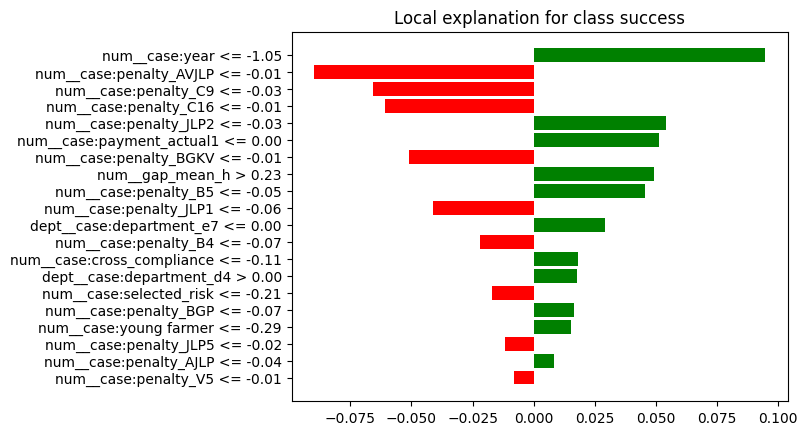

In [50]:
fig = exp.as_pyplot_figure()
import matplotlib.pyplot as plt
plt.show()

### 6.3 Top tokens (Positive, Negative, SVD component)

Displays the tokens and latent components most associated with success or failure. Positive values indicate terms supporting success predictions, while negatives mark risk-related expressions.

In [ ]:
def most_common_tokens(texts, k=25):
    tokens = " ".join(texts).split()
    return pd.DataFrame(Counter(tokens).most_common(k), columns=['token','count'])

succ_texts = text_tbl.loc[text_tbl['target_success']==1, 'text_doc'].fillna('')
fail_texts = text_tbl.loc[text_tbl['target_success']==0, 'text_doc'].fillna('')

print("Success class — top tokens:")
display(most_common_tokens(succ_texts, 25))
print("\nFailure class — top tokens:")
display(most_common_tokens(fail_texts, 25))

# SVD components: top words per component (first 5)
tfidf = combined_model.named_steps['prep'].named_transformers_['txt'].named_steps['tfidf']
svd   = combined_model.named_steps['prep'].named_transformers_['txt'].named_steps['svd']
terms = np.array(tfidf.get_feature_names_out())

for i in range(5):
    comp = svd.components_[i]
    top_idx = np.argsort(comp)[-15:][::-1]
    print(f"\nSVD component {i} — top words:")
    display(pd.DataFrame({'term': terms[top_idx], 'loading': comp[top_idx]}))


Success class — top tokens:


,token,count
0,application,1379152
1,complete,1315003
2,payment,902453
3,editing,806742
4,automatic,626238
5,main,568090
6,finish,505812
7,calculate,495630
8,begin,488558
9,save,284360



Failure class — top tokens:


,token,count
0,complete,742548
1,application,539423
2,editing,514884
3,payment,367706
4,document,342278
5,finish,326868
6,automatic,304570
7,begin,287912
8,parcel,271642
9,calculate,268848



SVD component 0 — top words:


,term,loading
0,application,0.397614
1,complete,0.375900
2,complete complete,0.368378
3,payment,0.262147
4,editing,0.257863
5,automatic,0.191512
6,payment application,0.174686
7,automatic automatic,0.161617
8,finish,0.158525
9,application payment,0.155695



SVD component 1 — top words:


,term,loading
0,geo parcel,0.311175
1,geo,0.311175
2,reported,0.265465
3,document geo,0.257051
4,reported reported,0.223674
5,document,0.134450
6,parcel document,0.125696
7,parcel,0.125696
8,declared,0.110859
9,editing begin,0.093151



SVD component 2 — top words:


,term,loading
0,inspection,0.299343
1,inspection inspection,0.276049
2,reported,0.238652
3,save,0.208952
4,reported reported,0.200785
5,save save,0.172932
6,site,0.168735
7,remote,0.150735
8,site site,0.149148
9,entitlement,0.144767



SVD component 3 — top words:


,term,loading
0,inspection,0.411622
1,inspection inspection,0.379739
2,site,0.226127
3,remote,0.213296
4,site site,0.198973
5,remote remote,0.184717
6,preparations,0.164568
7,application,0.153833
8,application application,0.146612
9,save save,0.127953



SVD component 4 — top words:


,term,loading
0,save,0.420848
1,change,0.287192
2,save save,0.251168
3,change change,0.189694
4,document,0.170809
5,editing save,0.147127
6,save calculate,0.127650
7,declared,0.125736
8,complete complete,0.111405
9,complete,0.106818


### 6.4 SHAP Numeric Only

Global SHAP values rank numeric features by their contribution to predictions. The visualization shows both importance and direction of influence across all cases.

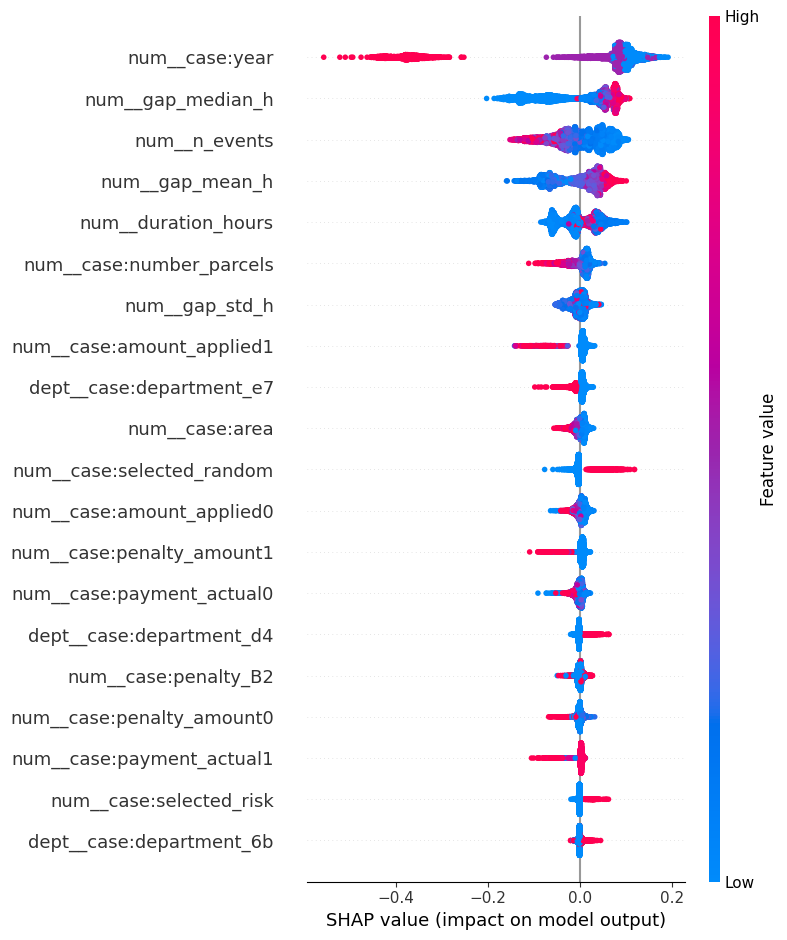

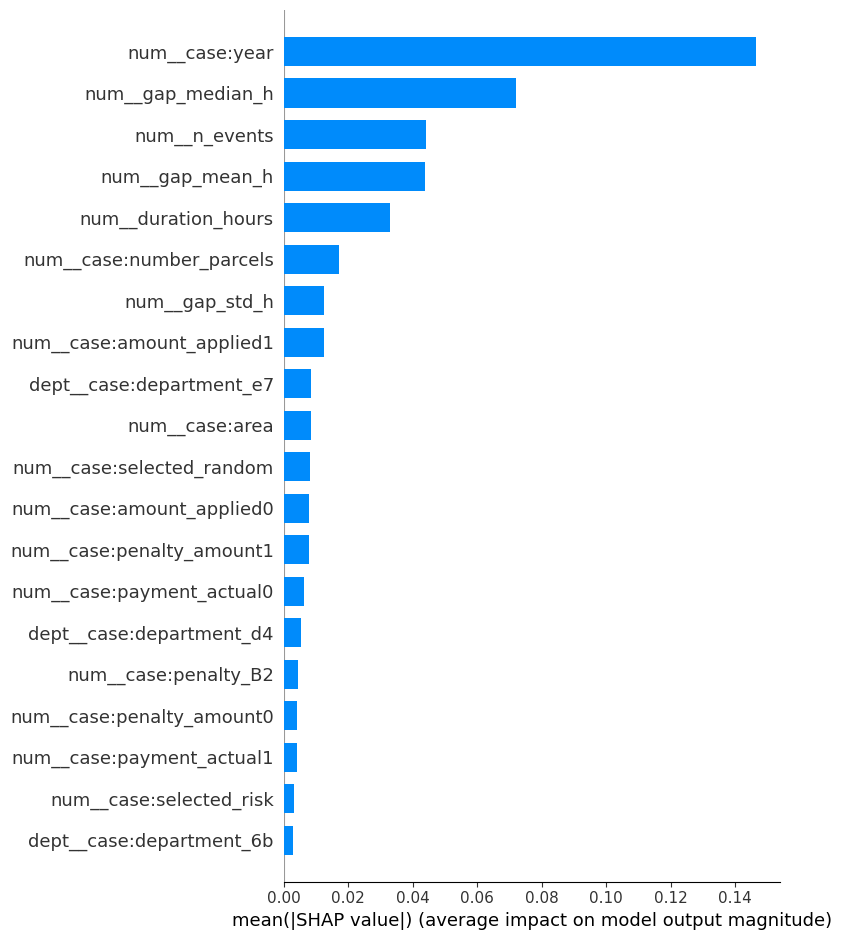

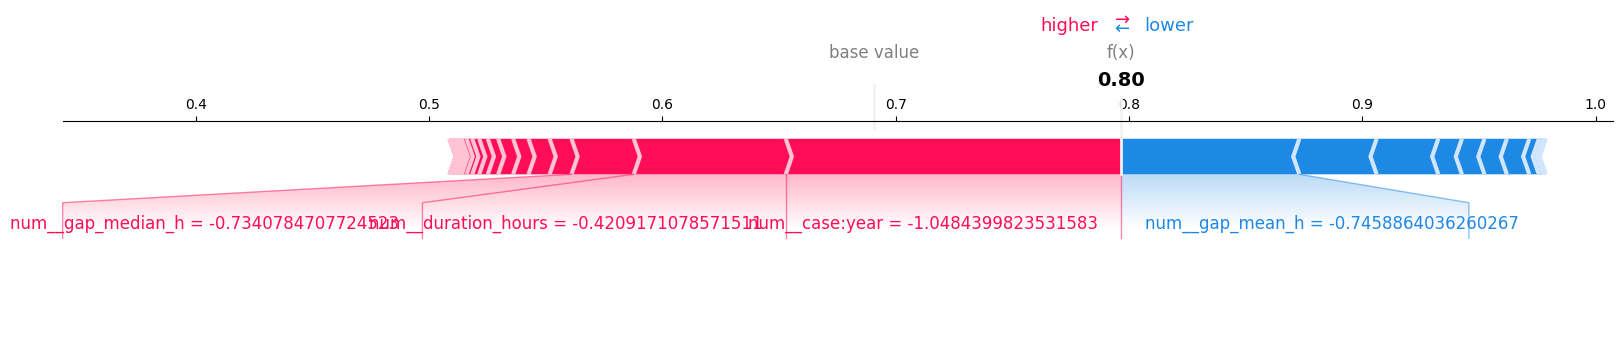

In [ ]:
shap.initjs()

# Pre-transform numeric features (so SHAP sees what model sees)
Xn_train_tx = numeric_preprocessor.fit_transform(Xn_train)
Xn_test_tx  = numeric_preprocessor.transform(Xn_test)
feat_names_num = numeric_preprocessor.get_feature_names_out()

rf = numeric_model.named_steps['clf']
expl_rf = shap.TreeExplainer(rf)
shap_values_rf = expl_rf.shap_values(Xn_test_tx)


In [ ]:
# Summary (global)
shap.summary_plot(shap_values_rf[1], Xn_test_tx, feature_names=feat_names_num, show=True)

In [ ]:
# Bar summary
shap.summary_plot(shap_values_rf[1], Xn_test_tx, feature_names=feat_names_num, plot_type='bar', show=True)

In [ ]:
# Local force plot for one example
i = 0
shap.force_plot(expl_rf.expected_value[1], shap_values_rf[1][i], Xn_test_tx[i], feature_names=feat_names_num, matplotlib=True)

### 6.5 SHAP Text-only

SHAP is applied to the text-only model to identify influential words or semantic components. Higher SHAP magnitudes correspond to stronger textual drivers of the prediction.

The option feature_dependence has been renamed to feature_perturbation!
The option feature_perturbation="independent" is has been renamed to feature_perturbation="interventional"!
The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, or maskers.Impute)


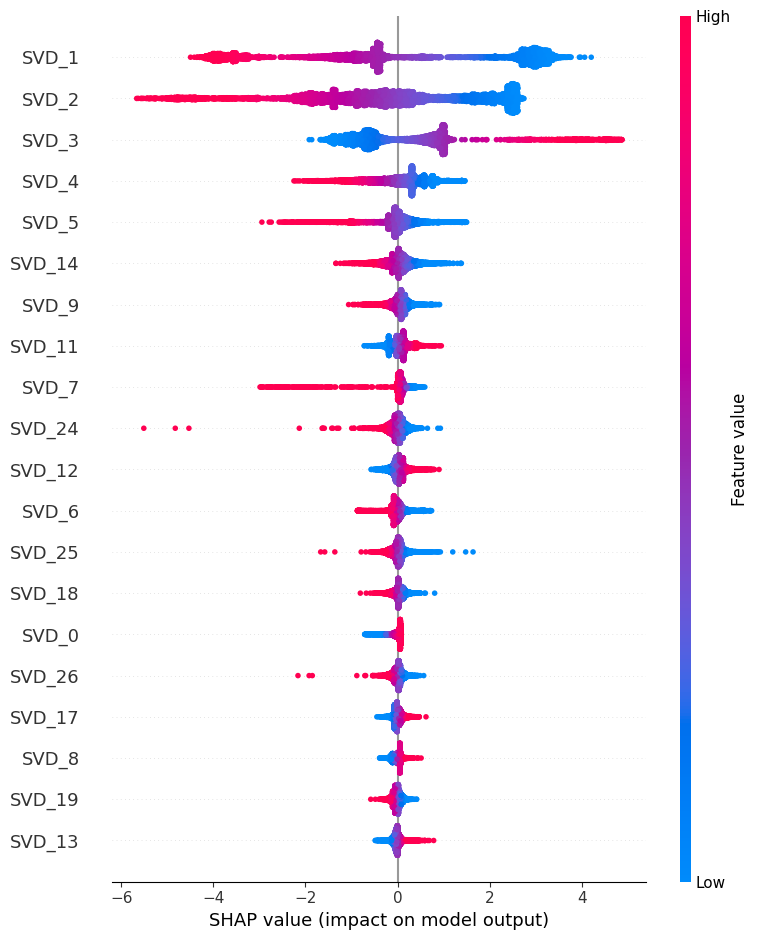

In [ ]:
prep_txt = text_model.named_steps['tfidf']
tfidf     = prep_txt.named_steps['tfidf']
svd       = prep_txt.named_steps['svd']
clf       = text_model.named_steps['clf']

# Transform text to SVD space
X_text_train_svd = prep_txt.transform(Xt_train)
X_text_test_svd  = prep_txt.transform(Xt_test)

expl_txt = shap.LinearExplainer(clf, X_text_train_svd, feature_dependence="independent")
shap_values_txt = expl_txt.shap_values(X_text_test_svd)

# Summary plot for SVD components
svd_features = [f"SVD_{i}" for i in range(svd.components_.shape[0])]
shap.summary_plot(shap_values_txt, X_text_test_svd, feature_names=svd_features, show=True)


#### Token Contribution

In [ ]:
mean_shap = shap_values_txt.mean(axis=0)
approx_term_weights = mean_shap @ svd.components_
terms = np.array(tfidf.get_feature_names_out())

top_pos = np.argsort(approx_term_weights)[-20:][::-1]
top_neg = np.argsort(approx_term_weights)[:20]

print("Top positive words (push success):")
display(pd.DataFrame({'term': terms[top_pos], 'approx_shap': approx_term_weights[top_pos]}))
print("\nTop negative words (push failure):")
display(pd.DataFrame({'term': terms[top_neg], 'approx_shap': approx_term_weights[top_neg]}))


Top positive words (push success):


,term,approx_shap
0,geo parcel,0.063359
1,geo,0.063359
2,document geo,0.049021
3,application application,0.048354
4,payment application,0.039860
5,payment,0.039695
6,calculate calculate,0.037152
7,reported,0.035039
8,declared,0.031538
9,application payment,0.030495



Top negative words (push failure):


,term,approx_shap
0,entitlement application,-0.112346
1,entitlement,-0.112346
2,application entitlement,-0.105470
3,main,-0.088985
4,main main,-0.088465
5,document parcel,-0.042070
6,change,-0.027702
7,editing save,-0.024343
8,editing,-0.023067
9,valid mail,-0.021112


### 6.6 SHAP combined model

Shows SHAP results for the multimodal model, integrating numeric and textual effects. It illustrates how both data types interact in shaping predictive outcomes.

The option feature_dependence has been renamed to feature_perturbation!
The option feature_perturbation="independent" is has been renamed to feature_perturbation="interventional"!
The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, or maskers.Impute)


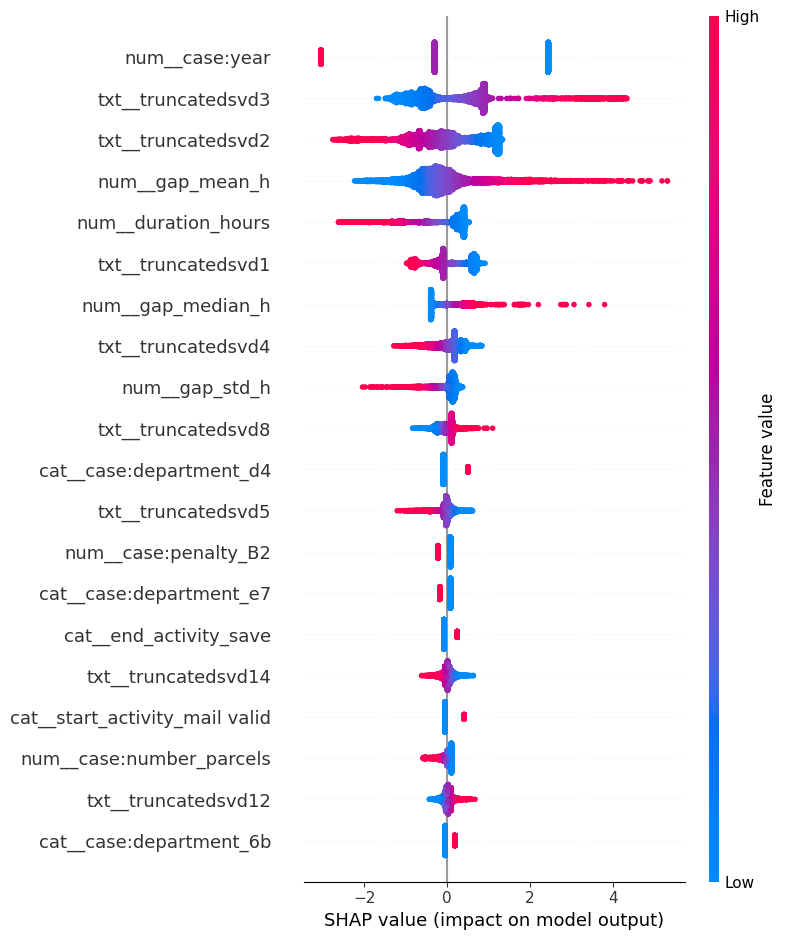

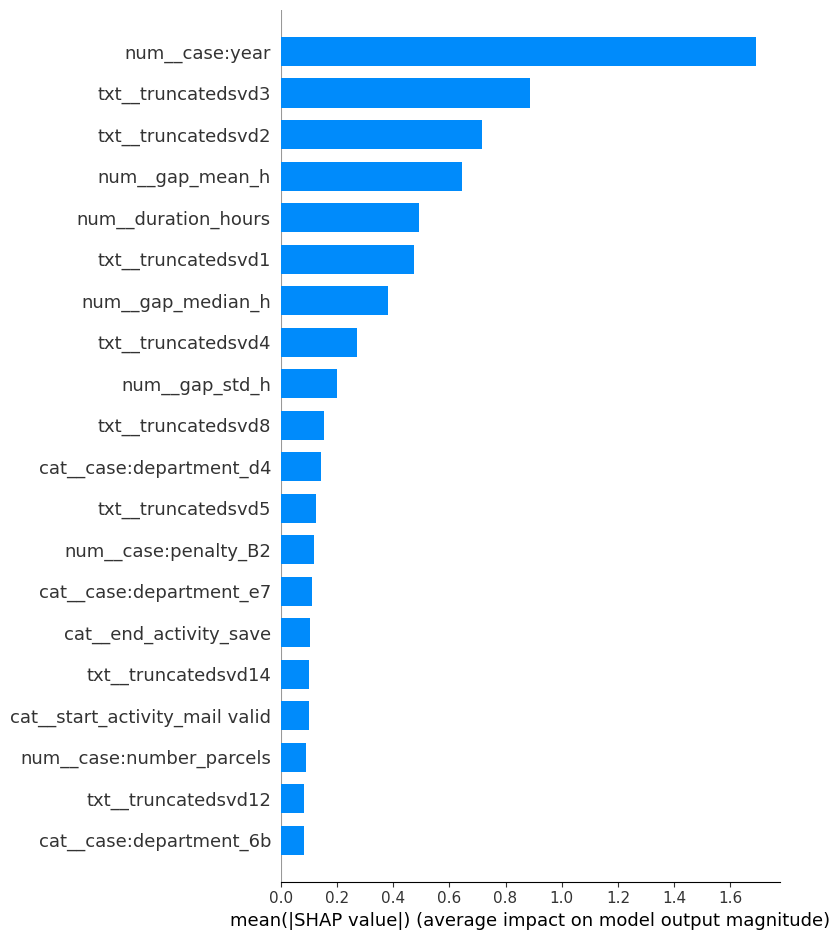

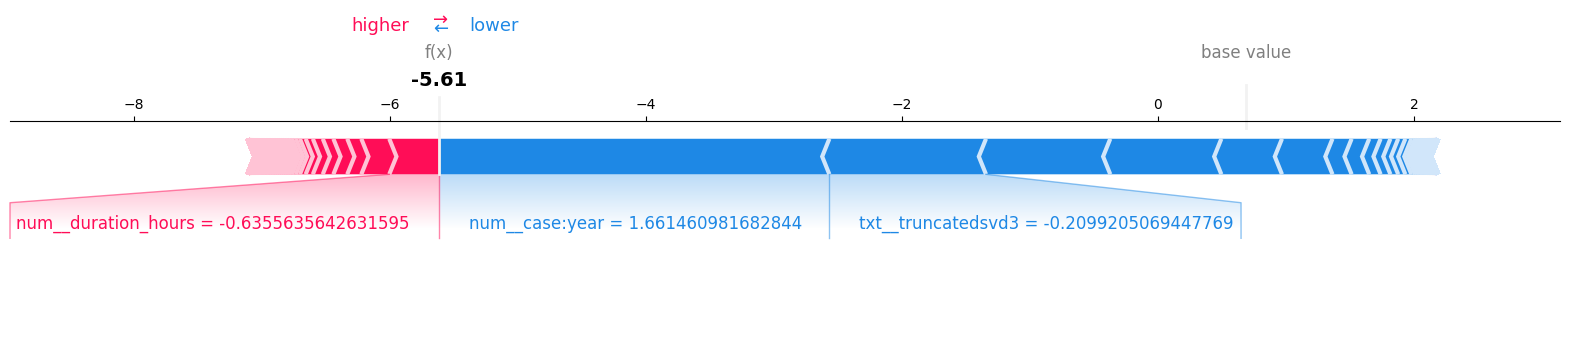

In [ ]:
shap.initjs()

prep = combined_model.named_steps['prep']
clf  = combined_model.named_steps['clf']

# Transform train/test
Xc_train_tx = prep.transform(Xc_train)
Xc_test_tx  = prep.transform(Xc_test)
feat_names  = prep.get_feature_names_out()

expl_comb = shap.LinearExplainer(clf, Xc_train_tx, feature_dependence="independent")
shap_vals_comb = expl_comb.shap_values(Xc_test_tx)

In [ ]:
# Global summary
shap.summary_plot(shap_vals_comb, Xc_test_tx, feature_names=feat_names, show=True)

In [ ]:
# Bar view
shap.summary_plot(shap_vals_comb, Xc_test_tx, feature_names=feat_names, plot_type='bar', show=True)

In [ ]:
# Local example
i = 1
shap.force_plot(expl_comb.expected_value, shap_vals_comb[i], Xc_test_tx[i], feature_names=feat_names, matplotlib=True)

## Aditional figures

Aggregated visualizations summarizing feature importance and model performance across pipelines.

### Top ten numeric features (permutation importance)

Highlights the ten most critical numeric attributes based on permutation importance, indicating their relative impact on accuracy.

In [24]:
imp10 = imp.head(10).iloc[::-1]
imp10.plot(kind='barh', x='feature', y='importance', title='Numeric – permutation importance (top 10)')
plt.xlabel('Δ accuracy'); plt.tight_layout(); plt.show()


NameError: name 'imp' is not defined

### Comparative performance summary (Acc/F1/AUC)

Compares the three models’ predictive metrics, emphasizing the benefit of combining structured and textual data.

In [25]:
def metrics_row(name, model, Xte, yte):
    p = model.predict_proba(Xte)[:,1]; pred=(p>=0.5).astype(int)
    return {'model':name,
            'accuracy':accuracy_score(yte,pred),
            'f1_weighted':f1_score(yte,pred,average='weighted'),
            'f1_macro':f1_score(yte,pred,average='macro'),
            'roc_auc':roc_auc_score(yte,p)}
cmp = pd.DataFrame([
    metrics_row('Numeric',  numeric_model,  Xn_test, yn_test),
    metrics_row('Text',     text_model,     Xt_test, yt_test),
    metrics_row('Combined', combined_model, Xc_test, yc_test),
]).round(4)
display(cmp)


NameError: name 'numeric_model' is not defined

In [26]:
!pip freeze

absl-py==1.3.0
altair==4.2.0
anyio==3.6.2
appdirs==1.4.4
appnope==0.1.3
argon2-cffi==21.3.0
argon2-cffi-bindings==21.2.0
astroid==2.11.7
asttokens==2.0.8
astunparse==1.6.3
attrs==24.3.0
autopep8==1.6.0
Babel==2.10.3
backcall==0.2.0
beautifulsoup4==4.11.1
bleach==5.0.1
blinker==1.5
blis==1.2.0
branca==0.5.0
bs4==0.0.2
cachetools==5.2.0
catalogue==2.0.10
certifi==2025.1.31
cffi==1.15.1
charset-normalizer==2.1.1
click==8.1.3
cloudpathlib==0.21.0
cloudpickle==2.2.0
colorama==0.4.5
commonmark==0.9.1
confection==0.1.5
cssselect==1.3.0
cvxopt==1.3.2
cycler==0.11.0
cymem==2.0.11
Cython==0.29.32
dask==2022.7.1
db-dtypes==1.0.4
deap==1.3.3
debugpy==1.6.3
decorator==5.1.1
defusedxml==0.7.1
deprecation==2.1.0
dill==0.3.6
entrypoints==0.4
etils==0.8.0
exceptiongroup==1.2.2
executing==1.1.1
fake-useragent==2.1.0
fastjsonschema==2.16.2
filelock==3.12.4
flake8==4.0.1
flatbuffers==22.9.24
folium==0.12.1.post1
fonttools==4.38.0
fr_core_news_sm @ https://github.com/explosion/spacy-models/releases/downloa